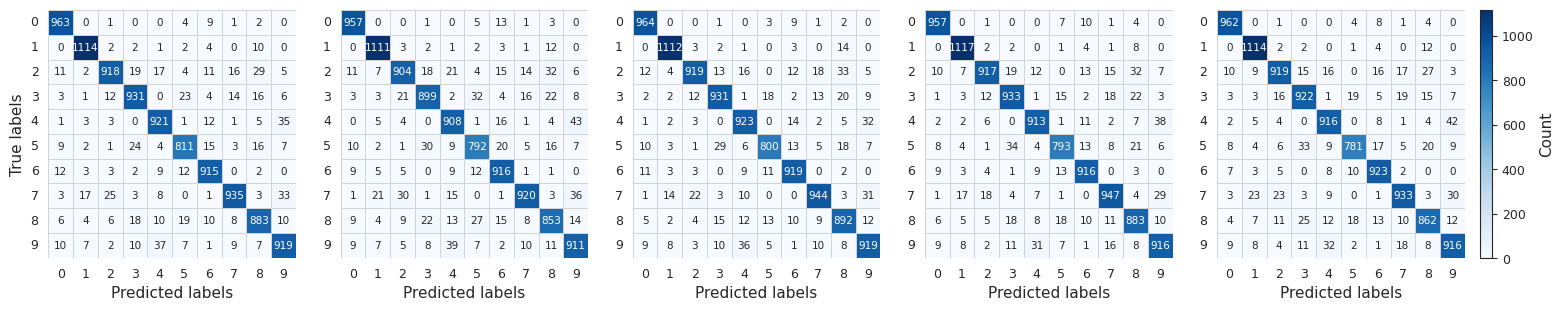

PosixPath('/home/subrat/Projects/neuromorphic/artifacts/combined_confusion_matrices.pdf')

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Publication-ready defaults
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

root = Path("/home/subrat/Projects/neuromorphic/artifacts")
folders = [
    root / "Strain_1_abstract",
    root / "Strain_0.4_abstract",
    root / "Strain_0.5_abstract",
    root / "Strain_0.67_abstract",
    root / "Flat_abstract",
]

titles = [
    "Strain = 0.1",
    "Strain = 0.4",
    "Strain = 0.5",
    "Strain = 0.67",
    "Flat",
]


def _looks_like_label_row(row: pd.Series) -> bool:
    vals = pd.to_numeric(row, errors="coerce")
    if vals.isna().any():
        return True
    seq = np.arange(len(vals))
    return np.allclose(vals.values, seq)


def _looks_like_label_col(col: pd.Series) -> bool:
    vals = pd.to_numeric(col, errors="coerce")
    if vals.isna().any():
        return True
    seq = np.arange(len(vals))
    return np.allclose(vals.values, seq)


def load_confusion_matrix(csv_path: Path) -> np.ndarray:
    df = pd.read_csv(csv_path, header=0)

    if str(df.columns[0]).lower().startswith("unnamed"):
        df = df.iloc[:, 1:]
    else:
        first_col_numeric = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        if first_col_numeric.isna().any():
            df = df.iloc[:, 1:]

    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")

    if df.shape[0] > 1 and _looks_like_label_row(df.iloc[0, :]):
        df = df.iloc[1:, :]
    if df.shape[1] > 1 and _looks_like_label_col(df.iloc[:, 0]):
        df = df.iloc[:, 1:]

    df = df.dropna(axis=0, how="any").dropna(axis=1, how="any")
    return df.values


matrices = []
for folder in folders:
    csv_path = folder / "confusion_matrix.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing {csv_path}")
    matrices.append(load_confusion_matrix(csv_path))

vmin = min(m.min() for m in matrices)
vmax = max(m.max() for m in matrices)

num = len(matrices)
fig, axes = plt.subplots(
    1,
    num,
    figsize=(3.8 * num, 3.8),
    gridspec_kw={"wspace": 0.18},
)
if num == 1:
    axes = [axes]

sns.set_style("white")

mappable = None
for idx, (ax, mat, title) in enumerate(zip(axes, matrices, titles)):
    hm = sns.heatmap(
        mat,
        ax=ax,
        cmap='Blues',
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".0f",
        annot_kws={"fontsize": 7.5},
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="lightgray",
    )
    if mappable is None:
        mappable = hm.collections[0]
    # ax.set_title(title, pad=8)
    ax.set_xlabel("Predicted labels")
    if idx == 0:
        ax.set_ylabel("True labels")
    else:
        ax.set_ylabel("")

    ax.set_xticks(np.arange(mat.shape[1]) + 0.5)
    ax.set_yticks(np.arange(mat.shape[0]) + 0.5)
    ax.set_xticklabels(range(mat.shape[1]), rotation=0)
    ax.set_yticklabels(range(mat.shape[0]), rotation=0)

cbar = fig.colorbar(mappable, ax=axes, fraction=0.028, pad=0.01, shrink=0.85)
cbar.set_label("Count")

output_path = root.parent / "artifacts" / "combined_confusion_matrices.pdf"
fig.savefig(output_path, bbox_inches="tight")
plt.show()

output_path